In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("AppleStockmarket.csv")

In [5]:
df=df[['Close']]
df

,Close
0,0.128348
1,0.121652
2,0.112723
3,0.115513
4,0.118862
...,...
10404,163.979996
10405,165.380005
10406,168.820007
10407,170.210007


In [7]:
df.shape

(10409, 1)

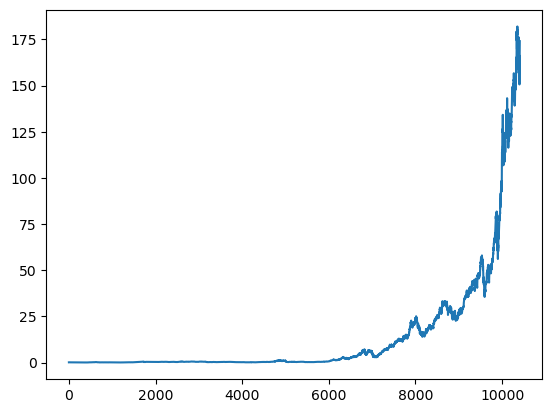

In [9]:
import matplotlib.pyplot as plt
plt.plot(df)

In [10]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df=scaler.fit_transform(np.array(df).reshape(-1,1))

In [11]:
df

array([[4.35483696e-04],
       [3.98684579e-04],
       [3.49613594e-04],
       ...,
       [9.27511961e-01],
       [9.35150965e-01],
       [9.56364315e-01]])

In [12]:
training_size=int(len(df)*0.65)
testing_size=len(df)-training_size
train_data,test_data=df[0:training_size,:],df[training_size:len(df),:1]

In [14]:
training_size,testing_size

(6765, 3644)

In [23]:
import numpy 
def create_database(dataset,time_step=1):
    dataX,dataY=[],[]
    for i in range(len(dataset)-time_step-1):
        a=dataset[i:(i+time_step),0]
        dataX.append(a)
        dataY.append(dataset[i+time_step,0])
    return numpy.array(dataX),numpy.array(dataY)

In [25]:
time_step=180
X_train,y_train=create_database(train_data,time_step)
X_test,y_test=create_database(test_data,time_step)

In [27]:
X_train.shape,y_train.shape

((6584, 180), (6584,))

In [29]:
X_test.shape,y_test.shape

((3463, 180), (3463,))

In [31]:
X_train=X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test=X_test.reshape(X_test.shape[0],X_test.shape[1],1)